# Descriptive Analysis

### Importing Libs

In [2]:
## basic libs
import pandas as pd
import numpy as np

## ploting libs
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## python system libs
import os, sys, json
sys.path.append('../')

## stats libs
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.regression.linear_model import OLS

## sklearn
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

### Loading data

In [3]:
df = pd.read_csv('../../data/04_datasets/dataset_0.csv')
dataset = df.iloc[:,1:].iloc[:,:-6]
df = df.iloc[:,:2]
df.date_time = pd.to_datetime(df.date_time)

In [4]:
df

,date_time,A612 - temperatura maxima na hora ant. (aut) (°c)
0,2006-11-04 01:00:00,23.9
1,2006-11-04 02:00:00,23.6
2,2006-11-04 03:00:00,23.6
3,2006-11-04 04:00:00,23.7
4,2006-11-04 05:00:00,23.6
...,...,...
124122,2020-12-31 19:00:00,30.6
124123,2020-12-31 20:00:00,29.6
124124,2020-12-31 21:00:00,28.1
124125,2020-12-31 22:00:00,26.6


<AxesSubplot:xlabel='date_time'>

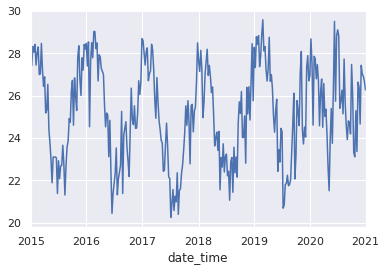

In [34]:
df[df["date_time"] >= '2015-01-01'].resample('w', on='date_time').mean().iloc[:,0].plot()

In [26]:
df.index = df.date_time

In [51]:
for i in range(15):
    print(df[(df["date_time"] >= '{}-01-01'.format(2006+i)) & (df["date_time"] <= '{}-01-01'.format(2007+i))].resample('d', on='date_time').mean().iloc[:,1].idxmax(axis=0, skipna=True))

2006-11-05 00:00:00
2007-01-07 00:00:00
2008-01-06 00:00:00
2009-01-04 00:00:00
2010-01-03 00:00:00
2011-01-02 00:00:00
2012-01-01 00:00:00
2013-01-06 00:00:00
2014-01-05 00:00:00
2015-01-04 00:00:00
2016-01-03 00:00:00
2017-01-01 00:00:00
2018-01-07 00:00:00
2019-01-06 00:00:00
2020-01-05 00:00:00


In [137]:
y = dataset.iloc[:,0]
x = dataset.iloc[:,1:]

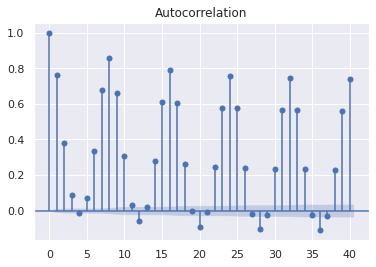

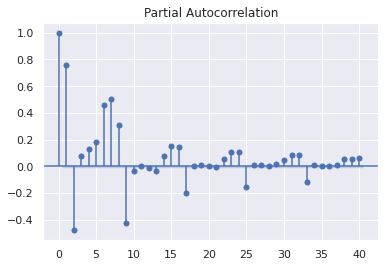

In [138]:
model = ElasticNet(alpha=1)
model.fit(x,y)
y_pred = model.predict(x)
error = y-y_pred
n_lags = 40
_ = plot_acf(error, lags=n_lags)
_ = plot_pacf(error, lags=n_lags)

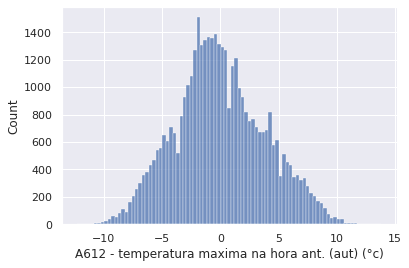

In [139]:
_ = sns.histplot(error)

In [140]:
error.describe()

count    4.137500e+04
mean     1.890430e-15
std      3.855329e+00
min     -1.229150e+01
25%     -2.591505e+00
50%     -2.915045e-01
75%      2.508495e+00
max      1.380850e+01
Name: A612 - temperatura maxima na hora ant. (aut) (°c), dtype: float64

In [44]:
serie_name = 'A612 - temperatura maxima na hora ant. (aut) (°c)'
serie = df[serie_name]

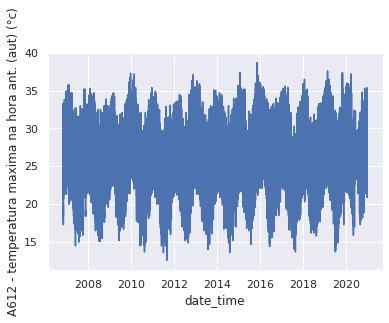

In [45]:
_ = sns.lineplot(data = df,x = 'date_time', y = serie_name)

In [83]:
def ranges(column_group, column_values=0, sigma=1.96):
    means = df.groupby(column_group).mean().iloc[:,column_values]
    sds = df.groupby(column_group).var().iloc[:,column_values].apply(lambda x: x**(0.5))/(df.shape[0]**0.5)
    inf_range = means+sigma*sds
    sup_range = means-sigma*sds
    return pd.concat([means,sds,sup_range,inf_range],axis=1)

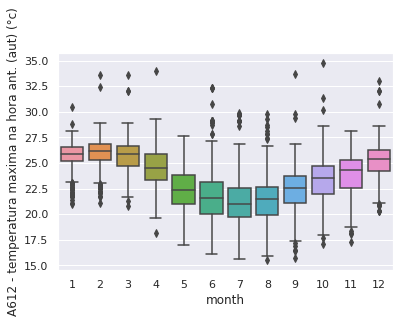

In [84]:
_ = sns.boxplot(data=df[df.hour == 0],y = 'A612 - temperatura maxima na hora ant. (aut) (°c)', x='month')

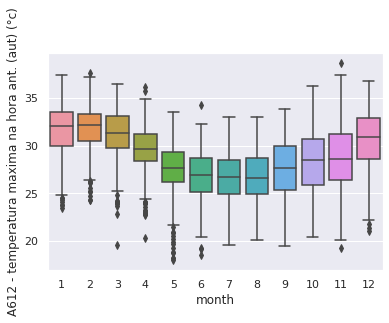

In [85]:
_ = sns.boxplot(data=df[df.hour == 15],y = 'A612 - temperatura maxima na hora ant. (aut) (°c)', x='month')